Business Understanding


In [1]:
##importing import libraries

In [2]:
## Data Manipulation
import pandas as pd
import numpy as np

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns

##Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

## Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Evaluation of the trained daata
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# # plots using seaborn
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
## loading data set

In [6]:
df=pd.read_csv('instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv')

In [7]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [8]:
df.shape

(2000, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [10]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [11]:
#checking missing values

In [16]:
df.isnull().sum() # no null values are present

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [15]:
df.duplicated().sum() # no duplicates in data

np.int64(0)

In [17]:
categorical_cols = df.select_dtypes(include="object").columns
numeric_cols = df.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

Categorical Columns:
Index(['batch_id', 'instructor_id', 'course_id'], dtype='object')

Numeric Columns:
Index(['completion_rate', 'avg_score_improvement', 'avg_quiz_score',
       'dropout_rate', 'avg_watch_time', 'assignment_submission_rate',
       'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')


In [18]:
df["instructor_id"].nunique() # no of instructors

120

In [19]:
df["course_id"].nunique() # no of coursess

25

In [20]:
 df["batch_id"].nunique() # no of batch

2000

##### Initial Observations

* The dataset contains 2000 course batches and 12 columns.
* There are 120 unique instructors teaching across multiple batches.
* The dataset contains no missing values, so no imputation is required.
* No duplicate records were found, indicating each row represents a unique course batch.
* The dataset includes a mix of identifier columns (batch_id, instructor_id, course_id) and numerical performance metrics related to learner outcomes, engagement, and feedback.

In [21]:
batch_counts = df.groupby("instructor_id").size()

batch_counts.describe()

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64

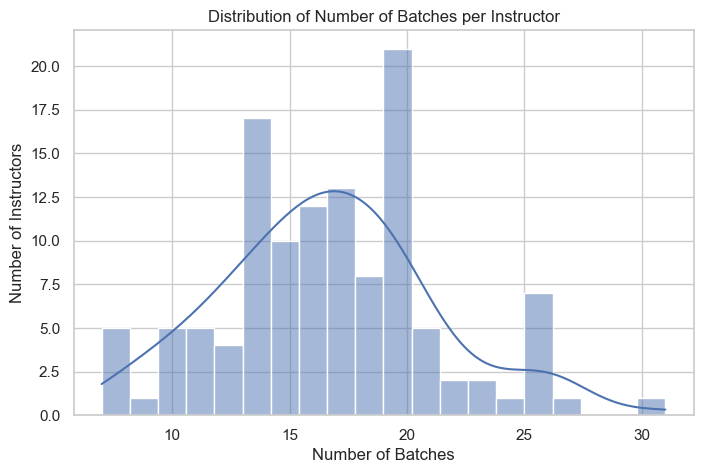

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(batch_counts, bins=20, kde=True)

plt.title("Distribution of Number of Batches per Instructor")
plt.xlabel("Number of Batches")
plt.ylabel("Number of Instructors")

plt.show()

In [24]:
numeric_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

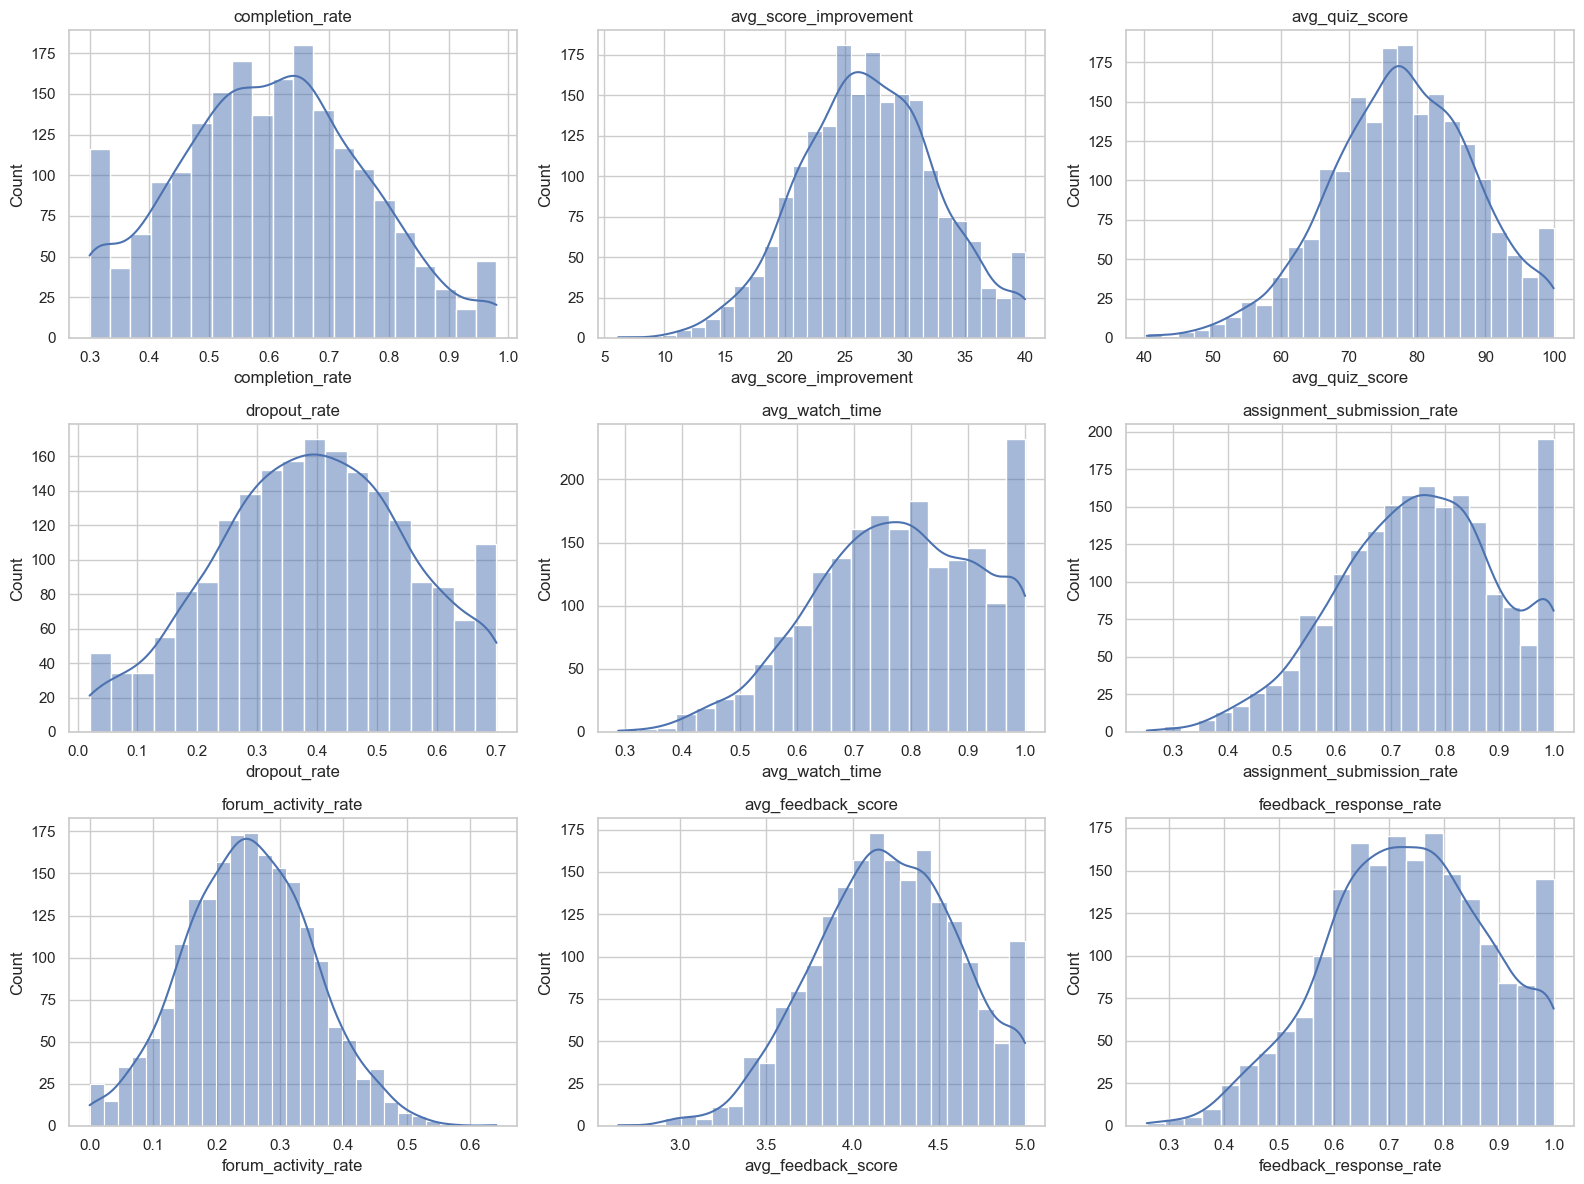

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

###Observations

* Most variables show continuous distributions with no obvious data entry errors.
* Completion rate and dropout rate appear bounded between 0 and 1, as expected.
* Feedback scores concentrated toward higher values, suggesting learners generally provide positive ratings.
* Some variables show mild skewness, but no severe irregularities are observed.

In [26]:
#outlier

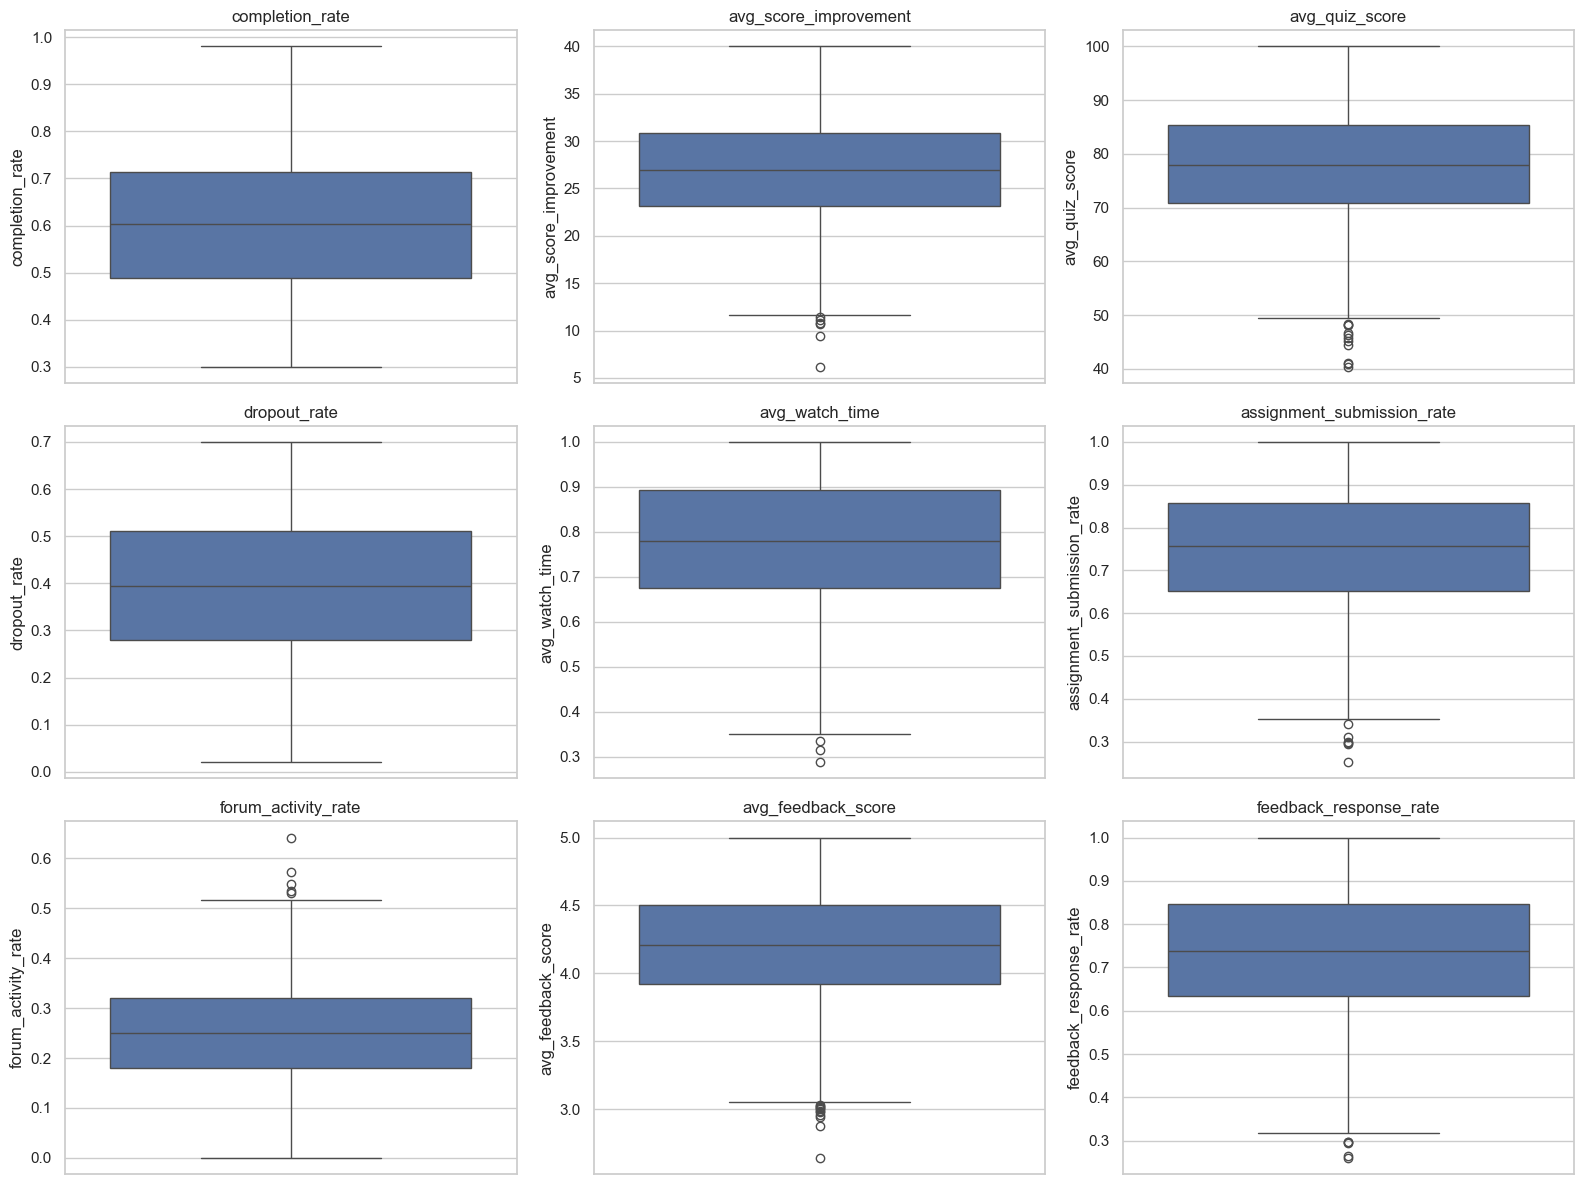

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

##Outlier Analysis

Several variables contain extreme observations. Since these values may represent genuinely high or low performing course batches rather than measurement errors.

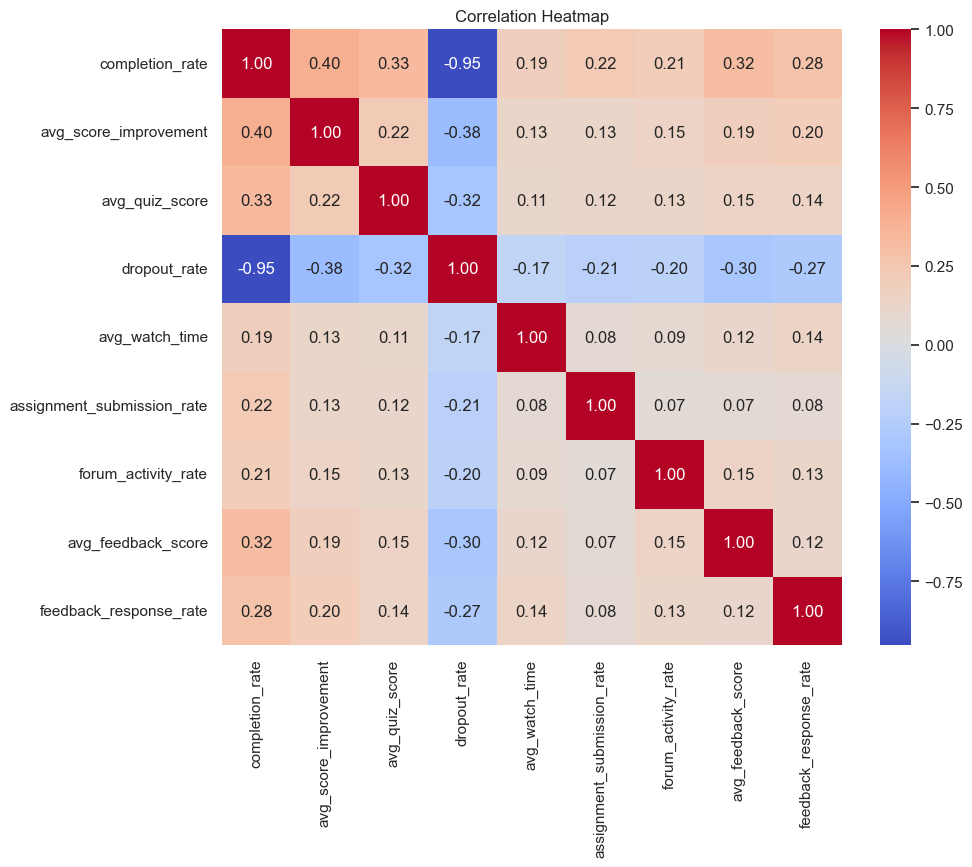

In [28]:
plt.figure(figsize=(10,8))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

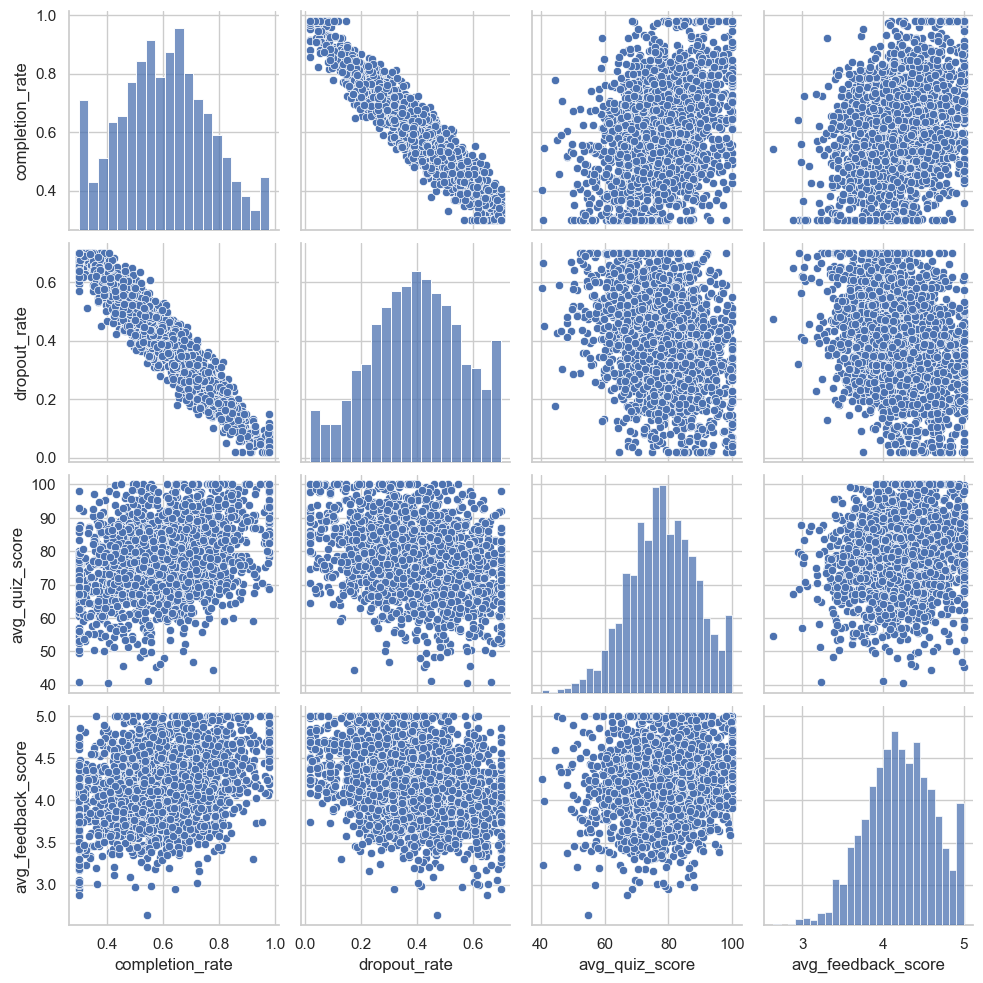

In [29]:
selected = [
    "completion_rate",
    "dropout_rate",
    "avg_quiz_score",
    "avg_feedback_score"
]

sns.pairplot(df[selected])

plt.show()

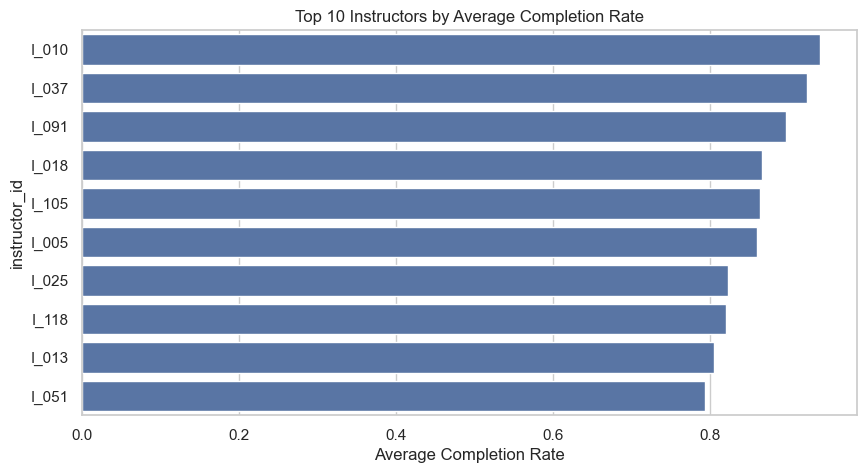

In [30]:
top_completion = (
    df.groupby("instructor_id")["completion_rate"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_completion.values,
    y=top_completion.index
)

plt.title("Top 10 Instructors by Average Completion Rate")
plt.xlabel("Average Completion Rate")

plt.show()

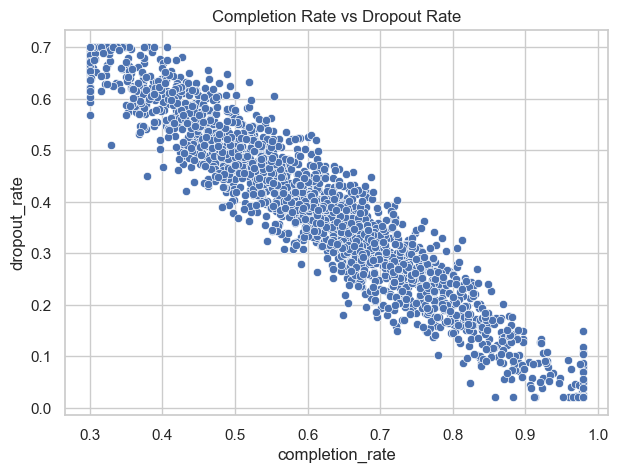

In [31]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="completion_rate",
    y="dropout_rate"
)

plt.title("Completion Rate vs Dropout Rate")

plt.show()

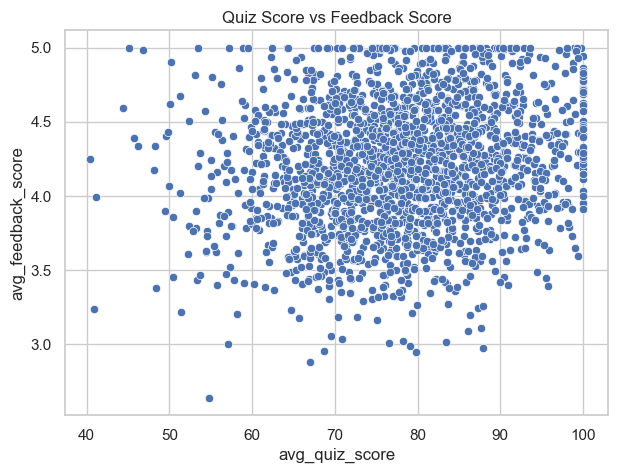

In [32]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="avg_quiz_score",
    y="avg_feedback_score"
)

plt.title("Quiz Score vs Feedback Score")

plt.show()

## EDA Summary

## Dataset
* Since every instructor has multiple observations, aggregating batch-level metrics to instructor-level statistics is appropriate.

## Correlation Analysis
* Completion rate and dropout rate have a very strong negative correlation (-0.95), indicating that batches with higher completion naturally have lower dropout.
* Average score improvement shows a moderate positive correlation (0.40) with completion rate, suggesting better learning outcomes are associated with higher completion.
* Average quiz score is positively correlated with completion rate (0.33).
* Learner engagement metrics (watch time, assignment submission, and forum activity) exhibit weak positive correlations with learner outcomes.
* Feedback-related variables also show weak positive relationships with completion and quiz performance.

## Key Observation
Completion rate and dropout rate capture nearly the same information but in opposite directions. Therefore, using both with equal importance may introduce redundancy when constructing the Instructor Effectiveness Score.

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

score_features = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

scaled_df = df.copy()

scaled_df[score_features] = scaler.fit_transform(df[score_features])

In [36]:
scaled_df["retention_rate"] = 1 - scaled_df["dropout_rate"]

In [37]:
scaled_df["outcome_score"] = (
    scaled_df["completion_rate"] +
    scaled_df["avg_score_improvement"] +
    scaled_df["avg_quiz_score"] +
    scaled_df["retention_rate"]
) / 4

In [38]:
scaled_df["engagement_score"] = (
    scaled_df["avg_watch_time"] +
    scaled_df["assignment_submission_rate"] +
    scaled_df["forum_activity_rate"]
) / 3

In [39]:
scaled_df["feedback_score"] = (
    scaled_df["avg_feedback_score"] +
    scaled_df["feedback_response_rate"]
) / 2

In [40]:
scaled_df["effectiveness_score"] = (
    0.50 * scaled_df["outcome_score"] +
    0.30 * scaled_df["engagement_score"] +
    0.20 * scaled_df["feedback_score"]
)

## Defining Instructor Effectiveness

Instructor effectiveness is defined as a composite score based on three dimensions:

1. Learner Outcomes (50%)
2. Learner Engagement (30%)
3. Learner Feedback (20%)

## Justification

* Learner outcomes receive the highest weight because improving student learning is the primary objective of an educational platform.
* Engagement metrics indicate how actively learners interact with the course and provide additional evidence of teaching effectiveness.
* Feedback metrics capture learner satisfaction but may be influenced by subjective opinions, so they receive a lower weight.

Dropout rate was converted into a retention measure before aggregation so that all variables follow the same interpretation: higher values indicate better performance.

Additionally, completion rate and dropout rate exhibit a very strong negative correlation (-0.95). By converting dropout into retention and averaging it with other outcome metrics, redundancy is reduced while still capturing valuable information about learner persistence.

In [41]:
scaled_df["effectiveness_score"].describe()

count    2000.000000
mean        0.573165
std         0.112860
min         0.181882
25%         0.496176
50%         0.574845
75%         0.646576
max         0.918663
Name: effectiveness_score, dtype: float64

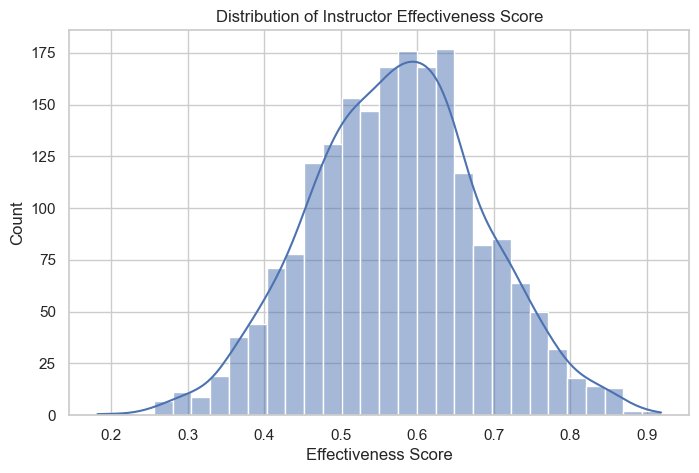

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    scaled_df["effectiveness_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Instructor Effectiveness Score")

plt.xlabel("Effectiveness Score")

plt.show()

In [43]:
instructor_df = (
    scaled_df
    .groupby("instructor_id")
    .agg({
        "completion_rate":"mean",
        "avg_score_improvement":"mean",
        "avg_quiz_score":"mean",
        "retention_rate":"mean",
        "avg_watch_time":"mean",
        "assignment_submission_rate":"mean",
        "forum_activity_rate":"mean",
        "avg_feedback_score":"mean",
        "feedback_response_rate":"mean",
        "effectiveness_score":"mean"
    })
)

In [44]:
batch_count = (
    df.groupby("instructor_id")
      .size()
      .rename("batch_count")
)

instructor_df = instructor_df.join(batch_count)

In [45]:
instructor_df.head()

,completion_rate,avg_score_improvement,avg_quiz_score,retention_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count
instructor_id,,,,,,,,,,,
I_001,0.358658,0.605253,0.646055,0.337363,0.672327,0.635317,0.375209,0.668547,0.587682,0.537324,25
I_002,0.633639,0.709411,0.693645,0.665891,0.771799,0.698745,0.451731,0.721621,0.708591,0.673072,20
I_003,0.688892,0.703843,0.691192,0.684076,0.745203,0.705706,0.462047,0.766972,0.746147,0.688608,18
I_004,0.232836,0.495047,0.625592,0.224616,0.709681,0.677277,0.352917,0.608662,0.623627,0.494478,17
I_005,0.823158,0.780993,0.762270,0.815098,0.785317,0.835679,0.520220,0.662095,0.708399,0.748861,19


In [46]:
instructor_df = instructor_df.reset_index()

In [47]:
instructor_df.shape

(120, 12)

## Instructor-Level Aggregation

Since instructors teach multiple course batches, the analysis was performed at the instructor level rather than the batch level.

Each numerical feature was aggregated using the mean to represent the instructor's average performance across all batches.

Additionally, the number of batches taught by each instructor was included as a feature (`batch_count`) to capture teaching experience within the available data.

The mean was selected because every instructor taught multiple batches (between 7 and 31), making the average a reliable summary statistic while reducing the influence of individual batch variability.


In [48]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

In [49]:
instructor_df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

In [50]:
X = instructor_df.drop(
    columns=[
        "instructor_id",
        "effectiveness_score",
        "effectiveness_tier"
    ]
)

y = instructor_df["effectiveness_tier"]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
print(instructor_df.shape)

print(instructor_df["effectiveness_tier"].value_counts())

X.head()

(120, 13)
effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


,completion_rate,avg_score_improvement,avg_quiz_score,retention_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count
0,0.358658,0.605253,0.646055,0.337363,0.672327,0.635317,0.375209,0.668547,0.587682,25
1,0.633639,0.709411,0.693645,0.665891,0.771799,0.698745,0.451731,0.721621,0.708591,20
2,0.688892,0.703843,0.691192,0.684076,0.745203,0.705706,0.462047,0.766972,0.746147,18
3,0.232836,0.495047,0.625592,0.224616,0.709681,0.677277,0.352917,0.608662,0.623627,17
4,0.823158,0.780993,0.762270,0.815098,0.785317,0.835679,0.520220,0.662095,0.708399,19


In [54]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [55]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       1.00      1.00      1.00         8
      Medium       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



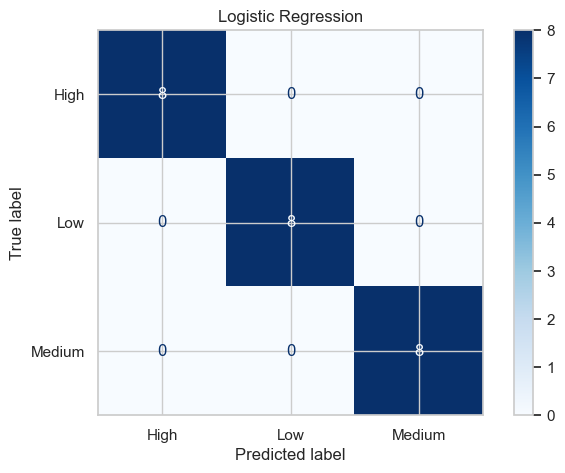

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression")
plt.show()

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



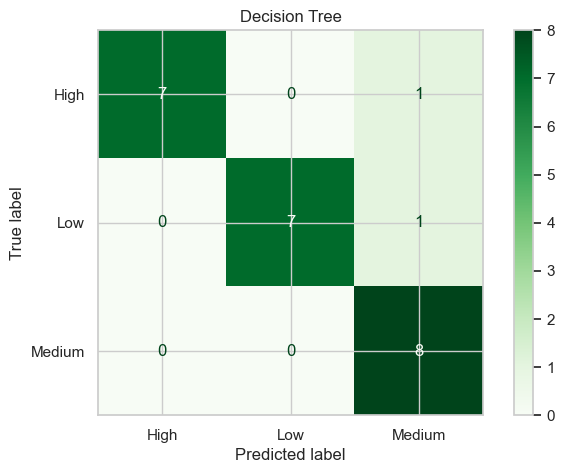

In [58]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens"
)

plt.title("Decision Tree")

plt.show()

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



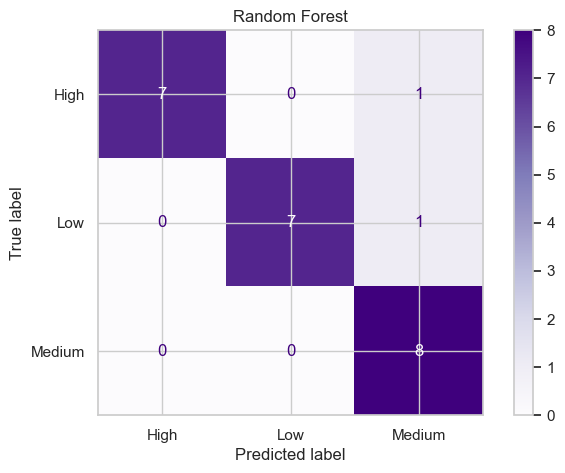

In [60]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Purples"
)

plt.title("Random Forest")

plt.show()

In [61]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,0.916667
2,Random Forest,0.916667


In [62]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

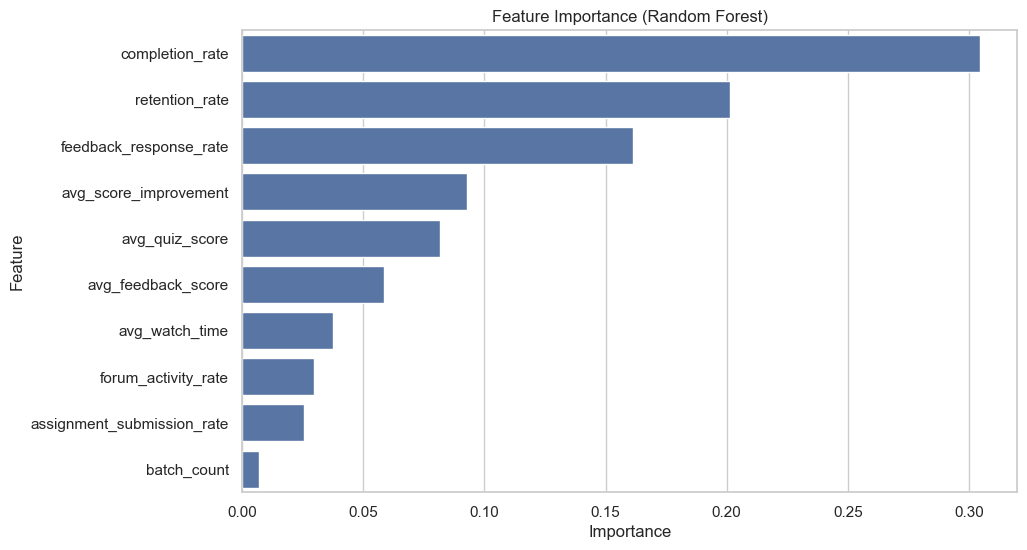

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")

plt.show()

### Feature Importance

The Random Forest model indicates that learner outcome metrics contribute most to predicting instructor effectiveness.

Completion rate, score improvement, and quiz score are among the strongest predictors, suggesting that instructors whose learners complete courses and demonstrate measurable learning gains are more likely to be classified as highly effective.

Engagement metrics such as assignment submission rate and watch time provide additional predictive value, while feedback metrics help distinguish instructors with similar academic outcomes.

## Model Evaluation

Accuracy alone is insufficient for evaluating a multi-class classification problem.

Precision measures how many instructors predicted for a tier actually belong to that tier.

Recall measures how many instructors within each tier are successfully identified.

F1-score balances precision and recall and is particularly useful when comparing models.

Since quantile based binning produced balanced classes (40 instructors per tier), 
accuracy is an appropriate summary metric, but precision, 
recall, and F1-score provide a more complete evaluation of model performance.

## Model Evaluation

Accuracy alone is insufficient for evaluating a multi-class classification problem.

Precision measures how many instructors predicted for a tier actually belong to that tier.

Recall measures how many instructors within each tier are successfully identified.

F1-score balances precision and recall and is particularly useful when comparing models.

Since quantile-based binning produced balanced classes (40 instructors per tier),
accuracy is an appropriate summary metric, but precision, 
recall, and F1-score provide a more complete evaluation of model performance.

## Model Evaluation

Accuracy alone is insufficient for evaluating a multi-class classification problem.

Precision measures how many instructors predicted for a tier actually belong to that tier.

Recall measures how many instructors within each tier are successfully identified.

F1-score balances precision and recall and is particularly useful when comparing models.

Since quantile-based binning produced balanced classes (40 instructors per tier), accuracy is an appropriate summary metric, but precision, recall, and F1-score provide a more complete evaluation of model performance.

In [71]:
## CONCLUSION 

### Which features most influenced instructor effectiveness?

The Random Forest feature importance analysis showed that learner outcome metrics such as completion rate, average score improvement, and average quiz score were the strongest predictors of instructor effectiveness.

These variables directly reflect whether learners successfully completed the course and demonstrated measurable learning gains. Since improving learner outcomes is the primary objective of an EdTech platform, it is reasonable that these variables have the greatest influence.

Engagement metrics such as assignment submission rate and average watch time also contributed to the model by indicating learner participation, while feedback-related metrics provided additional information about learner satisfaction.

### Which variables could be misleading?

Several variables may not solely reflect instructor quality.

- Average feedback score may be influenced by grading leniency, course difficulty, or learner expectations.
- Average watch time can increase because learners are highly engaged, but it may also increase if course material is difficult to understand.
- Quiz scores depend not only on teaching quality but also on assessment difficulty.
- Forum activity varies across different course types and learner communities.

These factors suggest that individual metrics should not be interpreted independently when evaluating instructors.

### Potential Failure Modes

This model has several limitations.

- It does not account for course difficulty.
- Learner background and prior knowledge are unavailable.
- Batch size is unknown.
- New instructors with limited teaching history may be difficult to evaluate reliably.
- Changes in curriculum or assessment design over time could affect learner outcomes without reflecting instructor performance.

As a result, predictions should be interpreted as supportive insights rather than objective measures of instructor quality.

### Additional Data That Would Improve the Analysis

The model could be improved by including:

- Batch size
- Course difficulty level
- Instructor teaching experience
- Years of experience
- Live session attendance
- Student demographics
- Previous instructor performance history
- Long-term learner retention
- Employment or certification outcomes after course completion

These variables would provide additional context and reduce potential bias.

### Should this model be used for instructor performance evaluation?

The model should not be used as the sole basis for evaluating instructor performance.

Although it identifies patterns associated with learner outcomes, engagement, and feedback, many external factors that influence these metrics are not represented in the dataset.

Instead, the model should be used as a decision-support tool to identify instructors who may benefit from additional coaching or to highlight teaching practices associated with successful learner outcomes. Final performance evaluations should also incorporate qualitative reviews, peer observations, and institutional context.

# Conclusion

This project developed an instructor effectiveness prediction pipeline using learner outcomes, engagement metrics, and feedback collected across multiple course batches.

A composite Instructor Effectiveness Score was designed by combining normalized measures of learner outcomes, engagement, and feedback. Batch-level data were aggregated to the instructor level, after which effectiveness tiers were created using quantile based binning.

Multiple machine learning models were evaluated, with Random Forest selected as the final model due to its strong predictive performance and ability to provide feature importance.

The analysis suggests that learner outcomes, particularly completion rate, score improvement, and quiz performance, are the strongest indicators of instructor effectiveness. However, the results should be interpreted cautiously because several important contextual variables were unavailable.

Overall, this project demonstrates how educational data can be transformed into actionable insights while acknowledging the practical and ethical limitations of predictive models.

### Additional Limitation

The target variable was constructed from the same set of observed features used for model training because no ground truth instructor effectiveness label was provided. Consequently, the model learns to reproduce the defined scoring framework rather than predict an independently observed measure of effectiveness. In practice, future work should use externally validated performance labels if available.